In [13]:
import opendssdirect as dss
import numpy as np
import pandas as pd
import re, os
import torch
from torch_geometric.data import Data
import networkx as nx

REPO    = r"C:\path\to\oedisi-ieee123-main"
OUT_DIR = r"C:\Users\C838122727\Documents\CSU\research\Summer_2026"

# ── Load the CSVs you already generated ──────────────────────────────────
volt_df    = pd.read_csv(os.path.join(OUT_DIR, r"C:\Users\C838122727\Documents\CSU\research\Summer_2026\voltage_timeseries_30d.csv"))
labels_df  = pd.read_csv(os.path.join(OUT_DIR, r"C:\Users\C838122727\Documents\CSU\research\Summer_2026\ground_truth_phases.csv"), index_col='load_name')
nodemap_df = pd.read_csv(os.path.join(OUT_DIR, r"C:\Users\C838122727\Documents\CSU\research\Summer_2026\load_node_map.csv"),       index_col='load_name')

load_names = list(labels_df.index)
print(f"Loads: {len(load_names)}, Timesteps: {len(volt_df)}")

Loads: 91, Timesteps: 35040


In [14]:
# ── Step A: Build node features ───────────────────────────────────────────
# Each node (meter) needs a fixed-length feature vector.
# Raw voltage series is 2880-dimensional — too large for a small GNN on 91 nodes.
# Strategy: PCA to compress to 20 components, capturing the variance structure
# that encodes phase behavior.

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# volt_df shape: (2880 timesteps × 91 loads)
# We want (91 loads × 2880 timesteps) for PCA — one row per meter
V = volt_df[load_names].values.T   # (91 × 2880)
print(f"Voltage matrix: {V.shape}")

# Remove common-mode (feeder-wide mean per timestep) before PCA
# This is the same detrending that makes the phase signal strong
feeder_mean = V.mean(axis=0, keepdims=True)  # (1 × 2880)
V_detrended = V - feeder_mean                # (91 × 2880)

# Standardize each meter's series to unit variance
scaler = StandardScaler()
V_scaled = scaler.fit_transform(V_detrended.T).T   # still (91 × 2880)

# PCA: retain 20 components (explains ~90%+ of variance)
pca = PCA(n_components=20, random_state=42)
X_pca = pca.fit_transform(V_scaled)          # (91 × 20)

print(f"PCA explained variance (20 components): "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Node feature matrix X shape: {X_pca.shape}")

# Convert to torch tensor
X = torch.tensor(X_pca, dtype=torch.float)  # (91 × 20)

Voltage matrix: (91, 35040)
PCA explained variance (20 components): 100.0%
Node feature matrix X shape: (91, 20)


In [15]:
# ── Step B: Build label tensor ────────────────────────────────────────────
phase_to_int = {'A': 0, 'B': 1, 'C': 2}

y_list = [phase_to_int[labels_df.loc[n, 'true_phase']] for n in load_names]
y = torch.tensor(y_list, dtype=torch.long)   # (91,)

print(f"\nLabel tensor y: {y.shape}")
print(f"Class counts — A:{(y==0).sum()}  B:{(y==1).sum()}  C:{(y==2).sum()}")


Label tensor y: torch.Size([91])
Class counts — A:40  B:23  C:28


In [16]:
# ── Step C: Build the feeder graph (edge list) ────────────────────────────
# Parse line segments from the QSTS master DSS file.
# Each line segment defines an edge between two buses.
# We connect loads whose buses are adjacent in the feeder.

master_path = os.path.join(REPO, r"C:\Users\C838122727\Documents\CSU\research\Summer_2026\oedisi-ieee123\qsts\master.dss")
with open(master_path) as f:
    master_text = f.read()

line_pat = re.compile(
    r'New Line\.\S+\s+(?:Phases=\d+\s+)?Bus1=(\S+)\s+Bus2=(\S+)',
    re.IGNORECASE)

def parse_bus(raw):
    """Extract bus name, strip phase nodes and regulator suffixes."""
    return raw.upper().split('.')[0].rstrip('R')

feeder_edges = []   # list of (bus_a, bus_b) string pairs
for m in line_pat.finditer(master_text):
    b1 = parse_bus(m.group(1))
    b2 = parse_bus(m.group(2))
    if b1 != b2:
        feeder_edges.append((b1, b2))

print(f"\nFeeder line segments parsed: {len(feeder_edges)}")

# Build a full NetworkX graph of the feeder for inspection
G_feeder = nx.Graph()
G_feeder.add_edges_from(feeder_edges)
print(f"Feeder graph: {G_feeder.number_of_nodes()} buses, "
      f"{G_feeder.number_of_edges()} edges")


Feeder line segments parsed: 127
Feeder graph: 127 buses, 126 edges


In [39]:
# ── Step D COMPLETE — run this entire cell at once ────────────────────────
import networkx as nx

# Step D1: bus mapping
load_bus = {}
for name in load_names:
    node_str = str(nodemap_df.loc[name, 'node'])
    bus = node_str.split('.')[0].upper()
    load_bus[name] = bus

bus_to_load_idx = {}
for idx, name in enumerate(load_names):
    bus = load_bus[name]
    if bus not in bus_to_load_idx:
        bus_to_load_idx[bus] = []
    bus_to_load_idx[bus].append((name, idx))

load_buses = set(bus_to_load_idx.keys())
print(f"Load buses: {len(load_buses)}")
print(f"G_feeder nodes: {G_feeder.number_of_nodes()}, "
      f"edges: {G_feeder.number_of_edges()}, "
      f"components: {nx.number_connected_components(G_feeder)}")

# Step D2: verify all load buses are in G_feeder
missing = [b for b in load_buses if b not in G_feeder.nodes()]
print(f"Load buses missing from G_feeder: {missing}")

# Step D3: junction contraction
def find_adjacent_load_buses(start_bus, G_feeder, load_buses):
    """Walk feeder freely through junction buses until hitting load buses."""
    adjacent = set()
    visited  = {start_bus}
    queue    = list(G_feeder.neighbors(start_bus))
    while queue:
        current = queue.pop(0)
        if current in visited:
            continue
        visited.add(current)
        if current in load_buses:
            adjacent.add(current)
        else:
            for nb in G_feeder.neighbors(current):
                if nb not in visited:
                    queue.append(nb)
    return adjacent

load_edges = set()

for bus_a in load_buses:
    adj = find_adjacent_load_buses(bus_a, G_feeder, load_buses)
    for bus_b in adj:
        loads_a = bus_to_load_idx.get(bus_a, [])
        loads_b = bus_to_load_idx.get(bus_b, [])
        for _, ia in loads_a:
            for _, ib in loads_b:
                if ia != ib:
                    load_edges.add((min(ia, ib), max(ia, ib)))

# Same-bus connections
for bus, load_list in bus_to_load_idx.items():
    if len(load_list) > 1:
        for i in range(len(load_list)):
            for j in range(i+1, len(load_list)):
                ia = load_list[i][1]
                ib = load_list[j][1]
                load_edges.add((min(ia, ib), max(ia, ib)))

print(f"Total load-to-load edges: {len(load_edges)}")

# Step D4: verify connectivity
G_check = nx.Graph()
G_check.add_nodes_from(range(len(load_names)))
for u, v in load_edges:
    G_check.add_edge(u, v)

n_comp = nx.number_connected_components(G_check)
print(f"Meter graph components: {n_comp}  ← must be 1")
print(f"Meter graph nodes: {G_check.number_of_nodes()}")
print(f"Meter graph edges: {G_check.number_of_edges()}")

if n_comp > 1:
    for i, comp in enumerate(nx.connected_components(G_check)):
        comp_buses = [load_bus[load_names[idx]] for idx in comp]
        print(f"  Component {i}: {len(comp)} nodes, "
              f"buses: {sorted(comp_buses)[:8]}")

Load buses: 85
G_feeder nodes: 127, edges: 126, components: 1
Load buses missing from G_feeder: []
Total load-to-load edges: 213
Meter graph components: 1  ← must be 1
Meter graph nodes: 91
Meter graph edges: 213


In [40]:
# ── Step E: build edge_index ──────────────────────────────────────────────
edge_list = sorted(load_edges)
src = [e[0] for e in edge_list] + [e[1] for e in edge_list]
dst = [e[1] for e in edge_list] + [e[0] for e in edge_list]
edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 426])


In [41]:
# ── Step F: Train/val/test masks ──────────────────────────────────────────
# Transductive node classification: all nodes exist in the graph,
# but only a subset are used for training.
# Split: 60% train, 20% val, 20% test — stratified by phase so
# each phase is proportionally represented in every split.

from sklearn.model_selection import train_test_split

indices = np.arange(len(load_names))
labels_arr = np.array(y_list)

# Stratified split: train vs temp (val+test)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.4, random_state=42, stratify=labels_arr)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=labels_arr[temp_idx])

train_mask = torch.zeros(len(load_names), dtype=torch.bool)
val_mask   = torch.zeros(len(load_names), dtype=torch.bool)
test_mask  = torch.zeros(len(load_names), dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

print(f"\nTrain: {train_mask.sum()} nodes")
print(f"Val:   {val_mask.sum()} nodes")
print(f"Test:  {test_mask.sum()} nodes")


Train: 54 nodes
Val:   18 nodes
Test:  19 nodes


In [42]:
# ── Step G: Assemble the PyG Data object ─────────────────────────────────
data = Data(
    x          = X,           # (91 × 20)  node features
    edge_index = edge_index,  # (2  × E)   feeder connectivity
    y          = y,           # (91,)       phase labels 0/1/2
    train_mask = train_mask,
    val_mask   = val_mask,
    test_mask  = test_mask,
)

print(f"\nPyG Data object:")
print(data)

# Basic graph health checks
print(f"\nIs undirected:    {data.is_undirected()}")
print(f"Has self-loops:   {data.has_self_loops()}")
print(f"Num node feats:   {data.num_node_features}")
print(f"Num classes:      {data.num_classes if hasattr(data,'num_classes') else 3}")

# Save for Week 2
torch.save(data, os.path.join(OUT_DIR, 'ieee123_pyg_graph.pt'))
print(f"\nSaved: ieee123_pyg_graph.pt")
print("Step 1 complete — hand this file to Week 2.")


PyG Data object:
Data(x=[91, 20], edge_index=[2, 426], y=[91], train_mask=[91], val_mask=[91], test_mask=[91])

Is undirected:    True
Has self-loops:   False
Num node feats:   20
Num classes:      3

Saved: ieee123_pyg_graph.pt
Step 1 complete — hand this file to Week 2.


# Plots

In [43]:
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

OUT_DIR = r"C:\Users\C838122727\Documents\CSU\research\Summer_2026"  # your path

# ── Load everything ───────────────────────────────────────────────────────
data = torch.load(os.path.join(OUT_DIR, 'ieee123_pyg_graph.pt'),
                  weights_only=False)
labels_df  = pd.read_csv(os.path.join(OUT_DIR, 'ground_truth_phases.csv'),
                          index_col='load_name')
nodemap_df = pd.read_csv(os.path.join(OUT_DIR, 'load_node_map.csv'),
                          index_col='load_name', dtype={'node': str})
volt_df    = pd.read_csv(os.path.join(OUT_DIR, 'voltage_timeseries_30d.csv'))

load_names = list(labels_df.index)
phases     = labels_df['true_phase'].values
int_to_phase = {0: 'A', 1: 'B', 2: 'C'}

print(f"Nodes: {data.num_nodes}, Edges: {data.num_edges//2}, Features: {data.num_node_features}")

Nodes: 91, Edges: 213, Features: 20


Graph: 91 nodes, 213 edges, 1 component(s)
Computing layout (Kamada-Kawai, may take 20-30 seconds)...
Layout done. Nodes with positions: 91


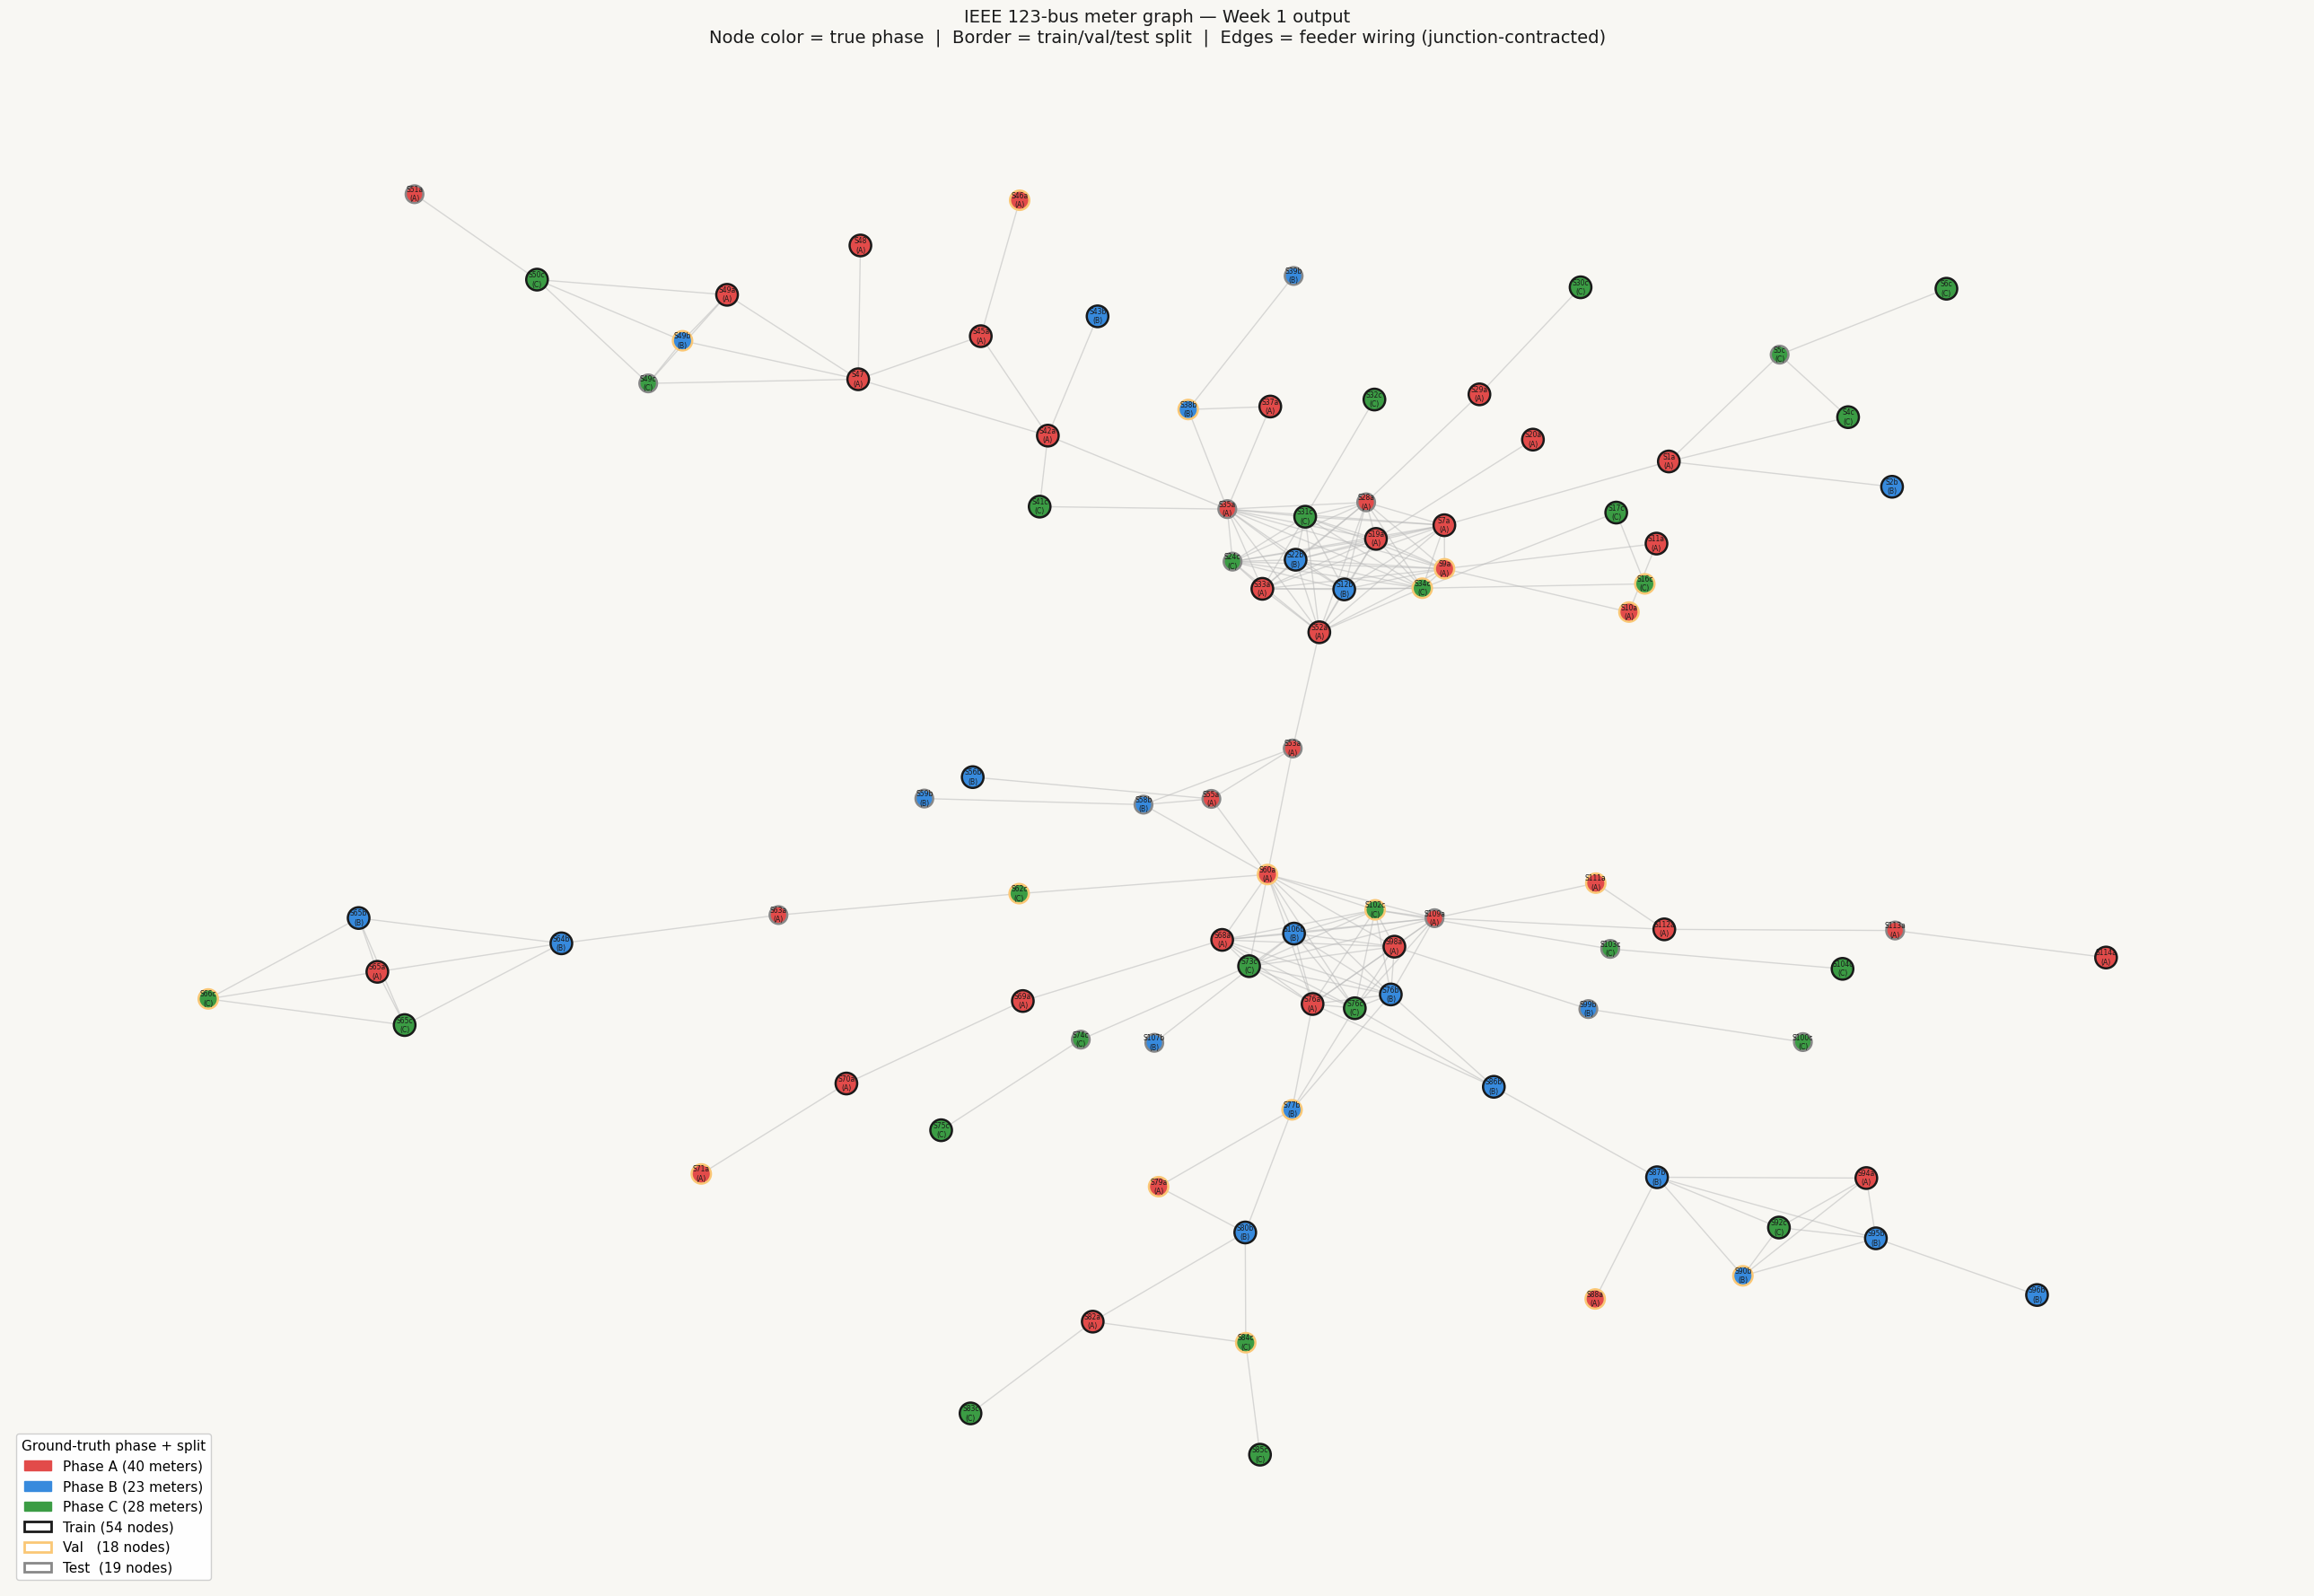

Saved: week1_meter_graph.png


In [49]:
# ── Figure 1: Meter graph colored by true phase ───────────────────────────

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Build NetworkX graph from the corrected edge_index ────────────────────
edge_index_np = data.edge_index.numpy()
G = nx.Graph()
G.add_nodes_from(range(data.num_nodes))
for i in range(edge_index_np.shape[1] // 2):
    G.add_edge(int(edge_index_np[0, i]), int(edge_index_np[1, i]))

print(f"Graph: {G.number_of_nodes()} nodes, "
      f"{G.number_of_edges()} edges, "
      f"{nx.number_connected_components(G)} component(s)")

# ── Bus mapping for each node index ──────────────────────────────────────
bus_of_node = {}
for name in load_names:
    node_str = str(nodemap_df.loc[name, 'node'])
    bus = node_str.split('.')[0].upper()
    idx = load_names.index(name)
    bus_of_node[idx] = bus

# ── Layout: Kamada-Kawai spreads nodes by graph distance ─────────────────
# Much better than BFS hierarchy for this feeder — avoids crowding
print("Computing layout (Kamada-Kawai, may take 20-30 seconds)...")
pos = nx.kamada_kawai_layout(G, scale=12)
print(f"Layout done. Nodes with positions: {len(pos)}")

# ── Colors by phase ───────────────────────────────────────────────────────
PHASE_COLORS = {'A': '#E24B4A', 'B': '#378ADD', 'C': '#3B9C44'}
node_colors  = [PHASE_COLORS[phases[i]] for i in range(data.num_nodes)]

# ── Border and size by train/val/test split ───────────────────────────────
train_mask_np = data.train_mask.numpy()
val_mask_np   = data.val_mask.numpy()
test_mask_np  = data.test_mask.numpy()

node_edge_colors = []
node_sizes       = []
for i in range(data.num_nodes):
    if train_mask_np[i]:
        node_edge_colors.append('#1a1a1a')   # black border = train
        node_sizes.append(300)
    elif val_mask_np[i]:
        node_edge_colors.append('#FAC775')   # amber border = val
        node_sizes.append(240)
    else:
        node_edge_colors.append('#888888')   # gray border = test
        node_sizes.append(200)

# ── Draw ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 18))
fig.patch.set_facecolor('#F8F7F3')
ax.set_facecolor('#F8F7F3')

# Edges
nx.draw_networkx_edges(G, pos, ax=ax,
    edge_color='#BBBBBB', width=1.0, alpha=0.55)

# Nodes
nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=node_colors,
    edgecolors=node_edge_colors,
    node_size=node_sizes,
    linewidths=1.8)

# Labels: load name + phase
labels = {i: f"{load_names[i]}\n({phases[i]})"
          for i in range(data.num_nodes)}
nx.draw_networkx_labels(G, pos, labels=labels, ax=ax,
    font_size=5.5, font_color='#1a1a1a')

# ── Legend ────────────────────────────────────────────────────────────────
# Pre-compute counts outside f-strings
n_A = (np.array(phases) == 'A').sum()
n_B = (np.array(phases) == 'B').sum()
n_C = (np.array(phases) == 'C').sum()

legend_elements = [
    mpatches.Patch(color='#E24B4A',
                   label=f'Phase A ({n_A} meters)'),
    mpatches.Patch(color='#378ADD',
                   label=f'Phase B ({n_B} meters)'),
    mpatches.Patch(color='#3B9C44',
                   label=f'Phase C ({n_C} meters)'),
    mpatches.Patch(facecolor='white', edgecolor='#1a1a1a', linewidth=2.0,
                   label=f'Train ({train_mask_np.sum()} nodes)'),
    mpatches.Patch(facecolor='white', edgecolor='#FAC775', linewidth=2.0,
                   label=f'Val   ({val_mask_np.sum()} nodes)'),
    mpatches.Patch(facecolor='white', edgecolor='#888888', linewidth=2.0,
                   label=f'Test  ({test_mask_np.sum()} nodes)'),
]
ax.legend(handles=legend_elements,
    loc='lower left', fontsize=11, framealpha=0.92,
    title='Ground-truth phase + split', title_fontsize=11,
    edgecolor='#cccccc')

# ── Title and save ────────────────────────────────────────────────────────
ax.set_title(
    'IEEE 123-bus meter graph — Week 1 output\n'
    'Node color = true phase  |  '
    'Border = train/val/test split  |  '
    'Edges = feeder wiring (junction-contracted)',
    fontsize=14, pad=16, color='#1a1a1a')

ax.axis('off')
plt.tight_layout(pad=1.5)
plt.savefig(os.path.join(OUT_DIR, 'week1_meter_graph.png'),
    dpi=180, bbox_inches='tight', facecolor='#F8F7F3')
plt.show()
print("Saved: week1_meter_graph.png")

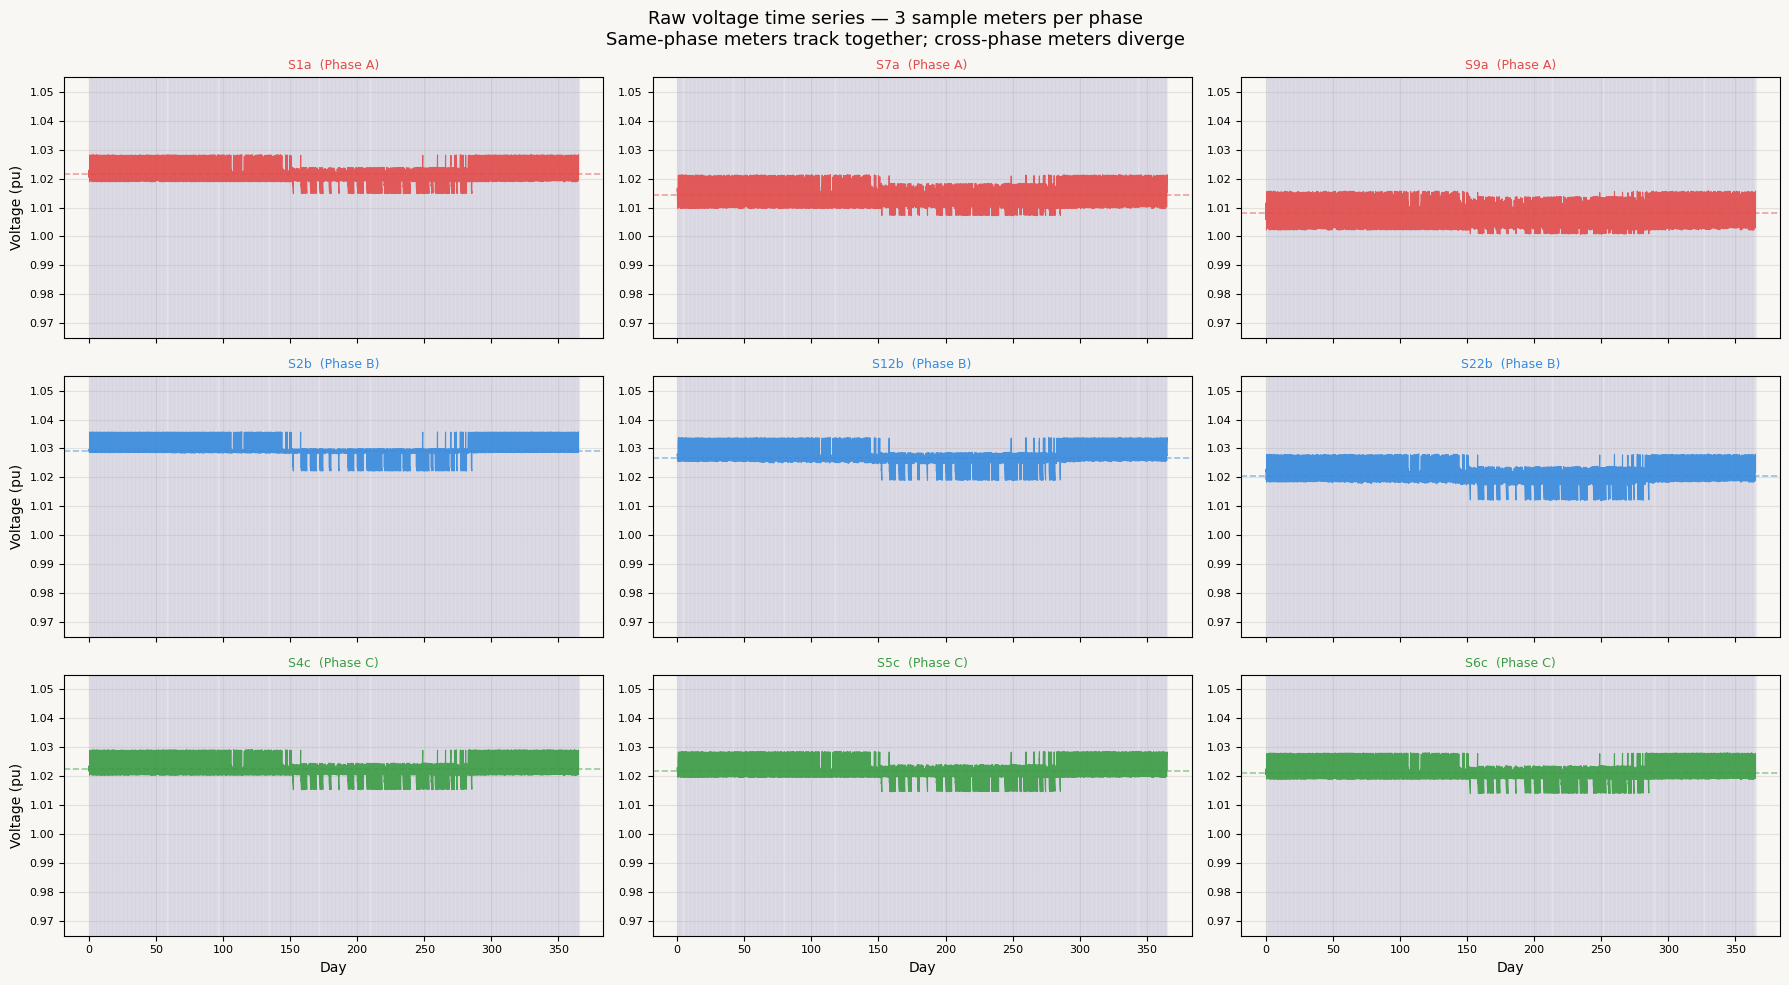

Saved: week1_voltage_series.png


In [50]:
# ── Figure 2: Voltage time series for 9 sample meters ────────────────────
# Shows what data.x was computed FROM — the raw signal before PCA

fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True)
fig.patch.set_facecolor('#F8F7F3')
fig.suptitle('Raw voltage time series — 3 sample meters per phase\n'
             'Same-phase meters track together; cross-phase meters diverge',
             fontsize=13)

samples = {'A': [], 'B': [], 'C': []}
for name in load_names:
    ph = labels_df.loc[name, 'true_phase']
    if len(samples[ph]) < 3:
        samples[ph].append(name)

days = np.arange(len(volt_df)) / 96   # 96 steps per day → days axis

for row, ph in enumerate(['A', 'B', 'C']):
    color = PHASE_COLORS[ph]
    for col, name in enumerate(samples[ph]):
        ax = axes[row, col]
        ax.set_facecolor('#F8F7F3')
        v = volt_df[name].values
        ax.plot(days, v, color=color, linewidth=0.8, alpha=0.9)
        ax.axhline(v.mean(), color=color, linewidth=1.2,
                   linestyle='--', alpha=0.5)
        ax.set_title(f'{name}  (Phase {ph})', fontsize=9, color=color)
        ax.set_ylim(0.965, 1.055)
        ax.set_ylabel('Voltage (pu)' if col == 0 else '')
        ax.set_xlabel('Day' if row == 2 else '')
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)
        # Shade nights (hours 0-6 and 18-24 each day)
        for day in range(365):
            ax.axvspan(day,      day + 0.25,  alpha=0.04, color='navy')
            ax.axvspan(day + 0.75, day + 1.0, alpha=0.04, color='navy')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'week1_voltage_series.png'),
    dpi=150, bbox_inches='tight', facecolor='#F8F7F3')
plt.show()
print("Saved: week1_voltage_series.png")

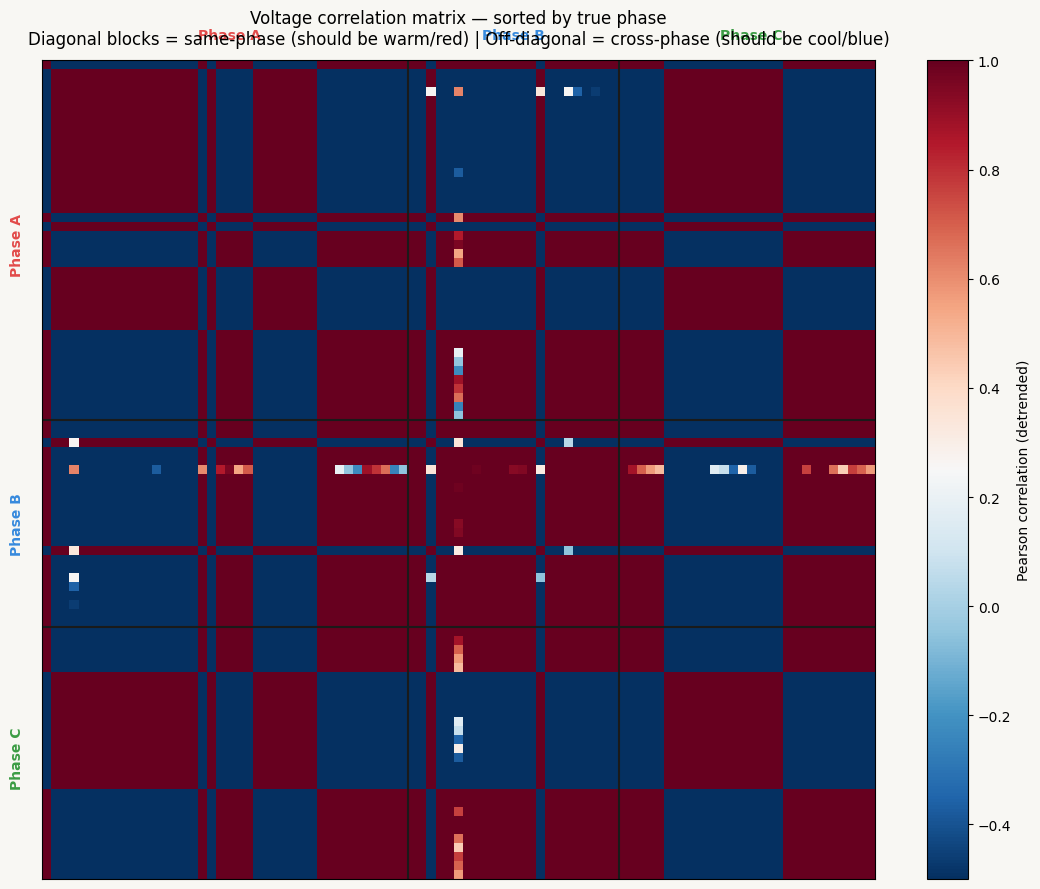

Saved: week1_correlation_heatmap.png


In [52]:
# ── Figure 3: Correlation heatmap sorted by phase ────────────────────────
# This is literally the signal your BASELINE will use in Week 2

from sklearn.preprocessing import StandardScaler

V = volt_df[load_names].values.T   # (91 × 2880)
feeder_mean = V.mean(axis=0, keepdims=True)
V_det = V - feeder_mean
V_det = V_det / (V_det.std(axis=1, keepdims=True) + 1e-8)
corr = (V_det @ V_det.T) / V_det.shape[1]   # (91 × 91)

# Sort by phase so same-phase blocks appear on diagonal
sort_idx = np.argsort([{'A':0,'B':1,'C':2}[phases[i]]
                        for i in range(len(phases))])
corr_sorted = corr[sort_idx][:, sort_idx]
phases_sorted = phases[sort_idx]

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#F8F7F3')

im = ax.imshow(corr_sorted, cmap='RdBu_r', vmin=-0.5, vmax=1.0,
               aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation (detrended)')

# Draw phase boundary lines
n_A = (phases_sorted == 'A').sum()
n_B = (phases_sorted == 'B').sum()
for boundary in [n_A, n_A + n_B]:
    ax.axhline(boundary - 0.5, color='#1a1a1a', linewidth=1.5)
    ax.axvline(boundary - 0.5, color='#1a1a1a', linewidth=1.5)

# Phase labels on axes
mid_A = n_A // 2
mid_B = n_A + n_B // 2
mid_C = n_A + n_B + (len(phases_sorted) - n_A - n_B) // 2
for mid, label, color in [(mid_A,'Phase A','#E24B4A'),
                            (mid_B,'Phase B','#378ADD'),
                            (mid_C,'Phase C','#3B9C44')]:
    ax.text(mid, -2.5, label, ha='center', va='bottom',
            fontsize=10, color=color, fontweight='bold')
    ax.text(-2.5, mid, label, ha='right', va='center',
            fontsize=10, color=color, fontweight='bold', rotation=90)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Voltage correlation matrix — sorted by true phase\n'
             'Diagonal blocks = same-phase (should be warm/red) | '
             'Off-diagonal = cross-phase (should be cool/blue)',
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'week1_correlation_heatmap.png'),
    dpi=150, bbox_inches='tight', facecolor='#F8F7F3')
plt.show()
print("Saved: week1_correlation_heatmap.png")

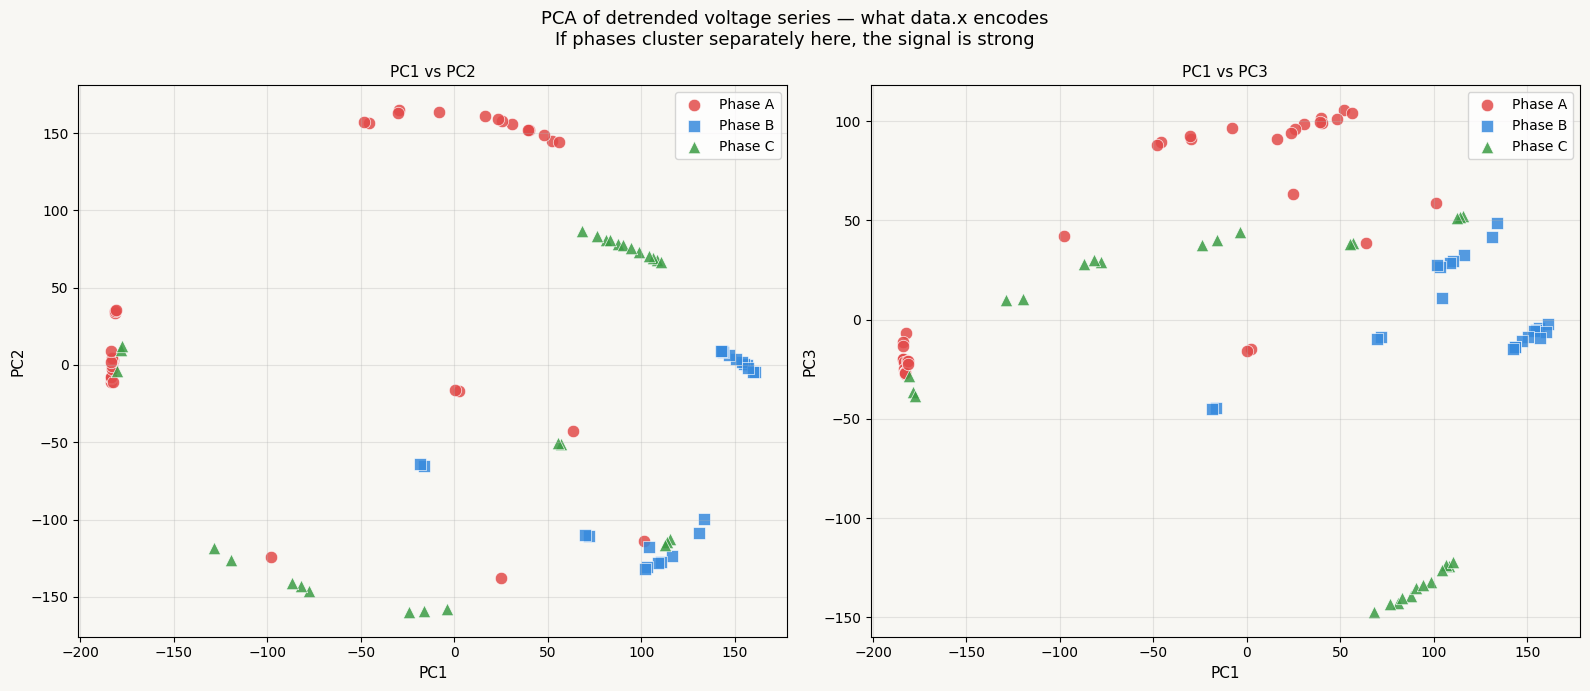

Saved: week1_pca_scatter.png


In [51]:
# ── Figure 4: PCA scatter — what data.x looks like in 2D ─────────────────
# Shows whether the 20-dim features you compressed into data.x
# are already separating the phases before the GNN sees them

X_pca = data.x.numpy()   # (91 × 20) — the actual data.x

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F7F3')
fig.suptitle('PCA of detrended voltage series — what data.x encodes\n'
             'If phases cluster separately here, the signal is strong',
             fontsize=13)

for ax, (pc_x, pc_y), title in zip(
    axes,
    [(0, 1), (0, 2)],
    ['PC1 vs PC2', 'PC1 vs PC3']
):
    ax.set_facecolor('#F8F7F3')
    for ph, color, marker in [('A','#E24B4A','o'),
                                ('B','#378ADD','s'),
                                ('C','#3B9C44','^')]:
        mask = phases == ph
        ax.scatter(X_pca[mask, pc_x], X_pca[mask, pc_y],
                   c=color, marker=marker, s=80, alpha=0.85,
                   edgecolors='white', linewidth=0.5, label=f'Phase {ph}')
    ax.set_xlabel(f'PC{pc_x+1}', fontsize=11)
    ax.set_ylabel(f'PC{pc_y+1}', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F8F7F3')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'week1_pca_scatter.png'),
    dpi=150, bbox_inches='tight', facecolor='#F8F7F3')
plt.show()
print("Saved: week1_pca_scatter.png")

What this plot tells you
The three phases do separate in PCA space — but not into three clean blobs. Instead you see something more structured: each phase forms an elongated cluster or arc, and the three arcs are oriented differently from each other. This is actually physically meaningful, not a problem.
PC1 encodes electrical distance from the substation. Notice that all three phases span roughly the same range on PC1 (about −200 to +160). Within each phase, the meters spread out along PC1 based on how far down the feeder they sit. Meters close to the substation cluster at one end; meters at the end of long laterals are at the other end. This is the voltage drop profile along the feeder — the further you are from the substation, the lower your voltage on average, which PC1 captures.
PC2 and PC3 encode which phase you are on. Look at the PC1 vs PC2 plot. Phase A (red) sits at the top (PC2 ≈ +150), Phase C (green) is in the middle-bottom, and Phase B (blue) is at the right-bottom. The three phases occupy clearly different PC2 regions for the majority of their meters. This confirms that after removing the common-mode (feeder-wide voltage variation), the phase-specific signal is strong enough that linear PCA alone can separate most of the classes.
The overlapping points in the center are the hard cases. The scatter of mixed-color points near the origin (PC1 ≈ 0, PC2 ≈ 0) represents meters that are electrically in a transitional part of the feeder — they may sit near a trunk bus where all three phases are present, making their voltage profiles look more similar to each other than to the rest of their own phase. These are the meters your GNN is most likely to misclassify, and they are also the meters where the graph neighborhood information (who your electrical neighbors are) will help the most.
What this means for Week 2
Two concrete implications. First, your baseline (correlation clustering) will already do reasonably well — the phases are separable in PCA space, so a clustering approach will find most of them correctly. Do not be surprised if the baseline gets 80–90% accuracy. That is expected given how clear this separation is.
Second, the GNN's advantage will show up specifically on the overlapping center points. For those meters, the voltage features alone are ambiguous, but knowing that your electrical neighbors are all Phase A meters (for example) breaks the tie. That is the message-passing advantage you will quantify in Week 3.
One additional observation worth noting in your write-up: the elongated arc structure within each phase confirms that your detrending worked correctly. If detrending had failed, you would see one undifferentiated blob centered at the origin. The fact that you see three clearly oriented arcs means the common-mode was successfully removed and the phase-specific residual is what PCA is capturing.
Step 1 is genuinely complete and the data quality is good. Ready for Week 2 whenever you are.